In [1]:
%%capture
!pip install lazypredict
!pip install psutil

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# General analysis packages
import numpy as np
import pandas as pd
import math
import psutil
import time
import threading

# Plotting packages
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, RobustScaler

# Model making
import xgboost as xgb
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import HuberRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import clear_output
from lazypredict.Supervised import LazyRegressor
from scipy.stats import uniform, randint
from lightgbm import LGBMRegressor


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv
/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv
/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset_info.txt


I was running out of memory while using LazyRegressor, so I have added this function to track RAM usage when the code is running.

In [3]:
mem_usage = []
timestamps = []
start_time = time.time()

def track_memory(interval=1):
    """Log RAM usage at regular intervals."""
    while True:
        mem_usage.append(psutil.virtual_memory().used / (1024 ** 3))  # Convert to GB
        timestamps.append(time.time() - start_time)
        time.sleep(interval)

tracking_thread = threading.Thread(target=track_memory, daemon=True)
tracking_thread.start()

# Data Exploration

In [4]:
# Load training and testing data
train_data = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
train_data_ext = pd.read_csv('/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv')
test_data = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
target = 'Listening_Time_minutes'

# compare columns in the dataframe
print(f'train_data columns: \n{train_data.columns}')
print(f'train_data_ext columns: \n{train_data_ext.columns}')
# same columns except for id, which will be dropped here
train_data.drop('id',axis=1,inplace=True)
test_data.drop('id',axis=1,inplace=True)

# Function to split target from training data; call this after any rows are dropped
def split_target(df,target):
    target_data = df[target].copy()
    df.drop(target,axis=1,inplace=True)
    return target_data

# Check to see if any rows are duplicates
def check_for_duplicated_rows(df):
    duplicates = df.duplicated()
    duplicated_rows = duplicates[duplicates]
    num_duplicates = len(duplicated_rows)
    print(f'There are {num_duplicates} duplicated rows')
    if num_duplicates>0:
        print('Removing these now ...')
        df.drop(df[df.duplicated()].index,inplace=True)

# Check for duplicated rows
check_for_duplicated_rows(train_data)
check_for_duplicated_rows(train_data_ext)
check_for_duplicated_rows(test_data)

# There are duplicates in train_data_ext, so make sure they were removed by the function
check_for_duplicated_rows(train_data_ext)

# Combine training data with the original dataset and split the target from it
train_data = pd.concat([train_data,train_data_ext])

# Remove rows for which the target doesn't exist before splitting target from training data
train_data = train_data.dropna(subset=[target])
target_data = split_target(train_data,target)

# combine training and testing data for ease of data exploration and feature engineering
combo_data = pd.concat([train_data,test_data])
index_split = int(len(train_data))
print(f'Index split = {index_split}')

# Separate categorical from numerical values
cat_cols = [col for col in combo_data.columns if 
            combo_data[col].dtype=='object'] 
num_cols = [col for col in combo_data.columns if 
           combo_data[col].dtype in ['float','int']]
all_cols = cat_cols+num_cols

# Will need to separately work on categorical and numerical data, so split into separate dataframes
cat_data = combo_data[cat_cols].copy()
num_data = combo_data[num_cols].copy()

print(f'Starting features for training data: \n{train_data.columns}')
print(f'Training data shape: {train_data.shape}')
print(f'Testing data shape: {test_data.shape}')
print(f'Combination data shape: {combo_data.shape}')
print(f'Categorical data shape: {cat_data.shape}')
print(f'Numerical data shape: {num_data.shape}')

train_data columns: 
Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment', 'Listening_Time_minutes'],
      dtype='object')
train_data_ext columns: 
Index(['Podcast_Name', 'Episode_Title', 'Episode_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Publication_Day', 'Publication_Time',
       'Guest_Popularity_percentage', 'Number_of_Ads', 'Episode_Sentiment',
       'Listening_Time_minutes'],
      dtype='object')
There are 0 duplicated rows
There are 2500 duplicated rows
Removing these now ...
There are 0 duplicated rows
There are 0 duplicated rows
Index split = 794868
Starting features for training data: 
Index(['Podcast_Name', 'Episode_Title', 'Episode_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Publication_Day', 'Publication_Time',
       'Guest_Popularity_percentag

Check if there are any null values

In [5]:
def print_nulls(df):
    print(f'Null values:\n{df.isnull().sum()}')

print_nulls(cat_data)

Null values:
Podcast_Name         0
Episode_Title        0
Genre                0
Publication_Day      0
Publication_Time     0
Episode_Sentiment    0
dtype: int64


In [6]:
print_nulls(target_data)

Null values:
0


In [7]:
print_nulls(num_data)

Null values:
Episode_Length_minutes         120323
Host_Popularity_percentage          0
Guest_Popularity_percentage    199336
Number_of_Ads                       1
dtype: int64


There are roughly 10% of episode length rows with missing values and roughly 20% of guest popularity percentage, but I suspect that both are important variables and they should not be dropped. After testing imputation with a constant value versus using the median, the median performed better.

The only null values are in the num_data dataframe. I tested dropping rows and I tested imputing with a constant value, but the best results I've gotten so far was when imputing with the median value and adding additional features which say whether a row contained a null value before imputation, so this is what is done below.

In [8]:
# First, add feature for whether a given feature has a NaN or not
col_with_nans = ['Episode_Length_minutes', 'Guest_Popularity_percentage', 'Number_of_Ads']
for col in col_with_nans:
    new_col = f'{col}_NaN'
    num_data[new_col] = num_data[col].isna().astype(int)

# Fill missing values with constant value that differentiates it from rows that did not have missing values
imputer_num = SimpleImputer(strategy='median')
num_data = pd.DataFrame(imputer_num.fit_transform(num_data),columns=num_data.columns)

print_nulls(num_data)

Null values:
Episode_Length_minutes             0
Host_Popularity_percentage         0
Guest_Popularity_percentage        0
Number_of_Ads                      0
Episode_Length_minutes_NaN         0
Guest_Popularity_percentage_NaN    0
Number_of_Ads_NaN                  0
dtype: int64


In [9]:
# Plot feature distributions
def plot_feature_distributions(df_list):
    df = pd.concat(df_list,axis=1)
    num_features = len(df.columns)
    print(f'Number of features to plot = {num_features}')

    ncols = 3
    nrows = math.ceil(num_features/ncols)
    width = 10*ncols
    height = 10*nrows
    fig, axes = plt.subplots(nrows=nrows,ncols=ncols, figsize=(width,height))
    for i, feature in enumerate(df.columns):
        sns.histplot(data=df, x=feature, ax=axes[i%nrows,i//nrows], color='purple')

print(num_data.columns)
print(cat_data.columns)
# Only plot a small random selection of rows because 1e6 rows takes too long to plot
num_rows = 100000
#plot_feature_distributions([num_data.sample(n=num_rows),cat_data.sample(n=num_rows)])
# plot_feature_distributions([num_data.sample(n=num_rows)])
# plot_feature_distributions([cat_data.sample(n=num_rows)])

Index(['Episode_Length_minutes', 'Host_Popularity_percentage',
       'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Length_minutes_NaN', 'Guest_Popularity_percentage_NaN',
       'Number_of_Ads_NaN'],
      dtype='object')
Index(['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day',
       'Publication_Time', 'Episode_Sentiment'],
      dtype='object')


Since there are categorical features I would like to keep that have lots of different categories, I'm going to use frequency encoding rather than one-hot encoding. One-hot encoding is very inefficient when this is the case.

# Feature Engineering

In [10]:
# Since there are important features with many categories, I'm using frequency encoding instead of one-hot encoding
def frequency_encoding(df,cat_cols):
    print(f'Freq encoding for {cat_cols}')
    new_names = [col+'_freq' for col in cat_cols]
    print(f'New column names: {new_names}')
    df[new_names] = df[cat_cols].apply(lambda col: col.map(col.value_counts(normalize=True)))
    
    df.drop(cat_cols,axis=1,inplace=True)
    return df

cat_data = frequency_encoding(cat_data,cat_cols)
cat_cols = cat_data.columns
cat_data.head()

Freq encoding for ['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']
New column names: ['Podcast_Name_freq', 'Episode_Title_freq', 'Genre_freq', 'Publication_Day_freq', 'Publication_Time_freq', 'Episode_Sentiment_freq']


,Podcast_Name_freq,Episode_Title_freq,Genre_freq,Publication_Day_freq,Publication_Time_freq,Episode_Sentiment_freq
0,0.02,0.01,0.11,0.14,0.26,0.33
1,0.02,0.01,0.11,0.14,0.24,0.33
2,0.02,0.01,0.07,0.13,0.26,0.33
3,0.02,0.01,0.11,0.15,0.24,0.33
4,0.02,0.01,0.10,0.15,0.24,0.33


In [11]:
# # The percentage-based values shouldn't be greater than 100
# percent_cols = ['Host_Popularity_percentage','Guest_Popularity_percentage']
# num_data[percent_cols] = num_data[percent_cols].clip(upper=100)

In [12]:
# Recombine categorical and numerical features into one dataframe
combo_data = pd.concat([cat_data.reset_index(drop=True), num_data.reset_index(drop=True)], axis=1)
del cat_data
del num_data

In [13]:
all_features = combo_data.columns
# Robust scaling
robust_data = RobustScaler()
robust_data.fit(combo_data)

combo_data = robust_data.transform(combo_data)

# RobustScalar turns the dataframe into a numpy array
# Turn it back into a pandas dataframe
combo_data = pd.DataFrame(combo_data,columns=all_features)

In [14]:
# See how important different features are to predicting the target
def plot_MI(df,tar):
    df_target = tar.copy()
    df_train = df
    mi = mutual_info_regression(df_train, df_target)
    features = df_train.columns
    mi_dict = dict(zip(features, mi))
    plt.figure(figsize=(35, 10),dpi=500)
    plt.bar(features, mi, color='skyblue')
    plt.title('Mutual Information Between Features and Target')
    plt.xlabel('Features')
    plt.ylabel('Mutual Information')
    plt.show()

    return mi_dict

# Note that this takes quite a while on the entire dataset
# mi_dict = plot_MI(combo_data[:index_split],target_data)

# # Remove features with a very low impact on the target
# for key, value in mi_dict.items():
#         print(f"{key}: {value}")
#         if value < 0.01:
#             combo_data.drop(key,axis=1,inplace=True)
#             print(f'{key} dropped')

In [15]:
# Make a plot of correlations between features
def plot_correlations(df):
    df_all = df.copy()
    corr_data = df_all.corr(method='pearson')  # Get the correlation matrix
    
    plt.figure(figsize=(15,15))
    sns.heatmap(data=corr_data, cmap='coolwarm', annot=True, fmt='.2g')
    
# plot_correlations(combo_data)

# Model Making

In [16]:
# Split testing and training data once again
y = target_data.copy()
X = combo_data[:index_split].copy()
X_test = combo_data[index_split:].copy()

del combo_data
print(f'Features to train on: \n{X.columns}')
print(f'Number of features: {len(X.columns)}')
print(type(X))
print(type(X_test))
print(type(y))

Features to train on: 
Index(['Podcast_Name_freq', 'Episode_Title_freq', 'Genre_freq',
       'Publication_Day_freq', 'Publication_Time_freq',
       'Episode_Sentiment_freq', 'Episode_Length_minutes',
       'Host_Popularity_percentage', 'Guest_Popularity_percentage',
       'Number_of_Ads', 'Episode_Length_minutes_NaN',
       'Guest_Popularity_percentage_NaN', 'Number_of_Ads_NaN'],
      dtype='object')
Number of features: 13
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [17]:
# Here I am using LazyRegressor to quickly evaluate how well a bunch of different models perform on this data
# Only testing on 30000 rows because I was running out of memory trying to do more
# test_rows = 30000
# X_trunc = X[:test_rows]
# y_trunc = y[:test_rows]
# x_train_lazy , x_test_lazy , y_train_lazy , y_test_lazy = train_test_split(X_trunc, y_trunc, test_size=0.2, random_state=0, shuffle=True)
# lazy_model = LazyRegressor(verbose=0, random_state=0, regressors='all')
# train_lazy , test_lazy = lazy_model.fit(x_train_lazy, x_test_lazy, y_train_lazy, y_test_lazy)
# test_lazy

Now I have a list of different models and how well they perform on a subset of the data. Here is a list of the top five to try:
- GradientBoostingRegressor
- LGBMRegressor
- HistGradientBoostingRegressor
- ~MLPRegressor~ (made performance worse)
- HuberRegressor 

# Determine best hyperparameters for different models

In [18]:
num_train = len(X)
X = X[:num_train]
y = y[:num_train]

def get_parameters_HistGradientBoostingRegressor(X_train,y_train):
    print('Finding best parameters for HistGradientBoostingRegressor')
    
    param_dist = {
        'learning_rate': uniform(0.01,0.1),
        'max_iter': randint(100,500),
        'max_depth': randint(4,16),
        'min_samples_leaf': randint(10,100),  # this model uses only min_samples_leaf
        'l2_regularization': uniform(0.0,1.0),
        'max_bins': randint(128,256),
    }

    hgb = HistGradientBoostingRegressor(random_state=42)
    
    random_search = RandomizedSearchCV(
        hgb,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )

    random_search.fit(X_train,y_train)
    print("Best HGB Parameters:", random_search.best_params_)

#get_parameters_HistGradientBoostingRegressor(X,y)

In [19]:
def get_parameters_HuberRegressor(X_train, y_train):
    print('Finding best parameters for HuberRegressor')

    param_dist = {
        'epsilon': uniform(1.1, 9.0),  # Epsilon > 1.0, typically between 1.1 and 10
        'alpha': uniform(1e-5, 1e-2),  # Regularization strength
        'max_iter': [100, 200, 300, 500, 1000],
        'fit_intercept': [True, False],
        'tol': uniform(1e-5, 1e-3)     # Tolerance for optimization
    }

    huber = HuberRegressor()

    random_search = RandomizedSearchCV(
        huber,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)
    print("Best Huber Parameters:", random_search.best_params_)

# get_parameters_HuberRegressor(X,y)

In [20]:
def get_parameters_GradientBoostingRegressor(X_train,y_train):
    print('Finding best parameters for GradientBoostingRegressor')
    param_dist = {
        'n_estimators': randint(100,500),
        'learning_rate': uniform(0.01,0.1),
        'max_depth': randint(4,16),
        'min_samples_split': randint(2,10),
        'min_samples_leaf': randint(1,10),
        'subsample': uniform(0.7,0.3),
        'max_features': ['sqrt','log2',None]
    }
    gbr = GradientBoostingRegressor()
    random_search = RandomizedSearchCV(
        gbr, 
        param_distributions=param_dist, 
        n_iter=10, 
        cv=3, 
        scoring='neg_root_mean_squared_error', 
        verbose=2, 
        n_jobs=-1
    )
    random_search.fit(X_train,y_train) 
    print("Best GBR Parameters:", random_search.best_params_)

#get_parameters_GradientBoostingRegressor(X,y)

In [21]:
def get_parameters_XGBoost(X_train,y_train):
    print('Finding best parameters for XGBoost')
    param_dist = {
        'n_estimators': randint(100,500),
        'learning_rate': uniform(0.01,0.1),
        'max_depth': randint(4,16),
        'subsample': uniform(0.7,0.3),
        'colsample_bytree': uniform(0.7,0.3),  # instead of max_features
        'gamma': uniform(0,5),
        'reg_alpha': uniform(0,1),
        'reg_lambda': uniform(0,1)
    }
    model = xgb.XGBRegressor()
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )
    random_search.fit(X_train,y_train)
    print("Best XGB Parameters:", random_search.best_params_)

#get_parameters_XGBoost(X,y)

In [22]:
def get_parameters_LGBMRegressor(X_train, y_train):
    print('Finding best parameters for LGBMRegressor')
    
    param_dist = {
        'n_estimators': randint(100,500),
        'learning_rate': uniform(0.01,0.1),
        'max_depth': randint(3,15),
        'num_leaves': randint(20,150),
        'min_child_samples': randint(5,50),
        'subsample': uniform(0.7,0.3),
        'colsample_bytree': uniform(0.7,0.3),
        'reg_alpha': uniform(0.0,1.0),
        'reg_lambda': uniform(0.0,1.0)
    }

    lgbm = LGBMRegressor(random_state=42)
    random_search = RandomizedSearchCV(
        lgbm,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )
    
    random_search.fit(X_train,y_train)
    print("Best LGBM Parameters:", random_search.best_params_)

#get_parameters_LGBMRegressor(X, y)

# Train individual models

In [23]:
def train_HuberRegressor(X_train, y_train):
    print('Starting to train HuberRegressor\n')

    params = {
        'epsilon': 6.309137428783002,
        'alpha': 0.004877974938442685,
        'max_iter': 200,
        'fit_intercept': True,
        'tol': 0.0008494667285558747
    }

    huber = HuberRegressor(**params)
    huber.fit(X_train, y_train)
    return huber

model_hr = train_HuberRegressor(X,y)

Starting to train HuberRegressor



In [24]:
def train_HistGradientBoostingRegressor(X_train, y_train):
    print('Starting to train HistGradientBoostingRegressor\n')
    
    params = {
        'max_iter': 427,
        'learning_rate': 0.09571615180145268,
        'max_depth': 11,
        'min_samples_leaf': 84,
        'l2_regularization': 0.7152624894796115,
        'max_bins': 206,
    }

    hgb = HistGradientBoostingRegressor(**params)
    hgb.fit(X_train,y_train)

    return hgb

model_hgb = train_HistGradientBoostingRegressor(X,y)

Starting to train HistGradientBoostingRegressor



In [25]:
def train_GradientBoostingRegressor(X_train,y_train):
    print('Starting to train GradientBoostingRegressor\n')
    params = {
        'n_estimators': 393,
        'learning_rate': 0.06693690822892108,
        'max_depth': 12,
        'min_samples_split': 7,
        'min_samples_leaf': 8,
        'subsample': 0.9414365090985378,
        'max_features': None
    }
    gbr = GradientBoostingRegressor(**params)
    gbr.fit(X_train,y_train)
    return gbr
    
model_gbr = train_GradientBoostingRegressor(X,y)

Starting to train GradientBoostingRegressor



In [26]:
def train_XGBoost(X_train,y_train):
    print('Starting to train XGBRegressor\n')
    params = {
        "n_estimators": 462,
        "learning_rate": 0.08154792163442738,
        "max_depth": 12,
        "subsample": 0.9058954745308208, 
        "colsample_bytree": 0.9456526638491439,
        "random_state": 0,
        "gamma": 0.33164411963508833,
        "reg_alpha": 0.01428218246267099,
        "reg_lambda": 0.8988143668046589
    }
    # XGBoost model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train,y_train)
    return model

model_xgb = train_XGBoost(X,y)

Starting to train XGBRegressor



In [27]:
def train_LGBMRegressor(X_train, y_train):
    print('Starting to train LGBMRegressor\n')
    params = {
        'n_estimators': 457,
        'learning_rate': 0.014915560132499209,
        'max_depth': 3,
        'num_leaves': 72,
        'min_child_samples': 19,
        'subsample': 0.7381421172094151,
        'colsample_bytree': 0.9449478096939333,
        'reg_alpha': 0.685559421931073,
        'reg_lambda': 0.3105632580080139,
        'random_state': 42
    }
    lgbm = LGBMRegressor(**params)
    lgbm.fit(X_train,y_train)
    return lgbm

model_LGBM = train_LGBMRegressor(X,y)

Starting to train LGBMRegressor

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 794868, number of used features: 12
[LightGBM] [Info] Start training from score 45.443291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

# Train stacking model containing specified models

In [28]:
def train_StackingModel(X,y):
    print('Creating stacking model\n')
    cv_fold = KFold(n_splits= 5,shuffle=True,random_state=42)
    model = StackingRegressor(
        estimators=[
            #('mlp', model_mlp), #performed better without MLP
            ('hr', model_hr),
            ('hgb', model_hgb),
            ('gbr', model_gbr),
            ('xgb', model_xgb),
            ('LGBM', model_LGBM), 
        ],
        cv=cv_fold
    )
    
    model.fit(X,y)
    return model

model = train_StackingModel(X,y)
prediction = model.predict(X_test)

Creating stacking model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 794868, number of used features: 12
[LightGBM] [Info] Start training from score 45.443291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [29]:
def SaveOutputFilesForCompetition(df,preds):
    print('Saving output files\n')
    idx_array = np.arange(750000,1000000,dtype=int)
    df_idx = pd.Series(idx_array)
    print(df_idx)
    output = pd.DataFrame({'id': df_idx,
                       target: preds})
    output.to_csv('submission.csv', index=False)
SaveOutputFilesForCompetition(X_test,prediction)

Saving output files

0         750000
1         750001
2         750002
3         750003
4         750004
           ...  
249995    999995
249996    999996
249997    999997
249998    999998
249999    999999
Length: 250000, dtype: int64


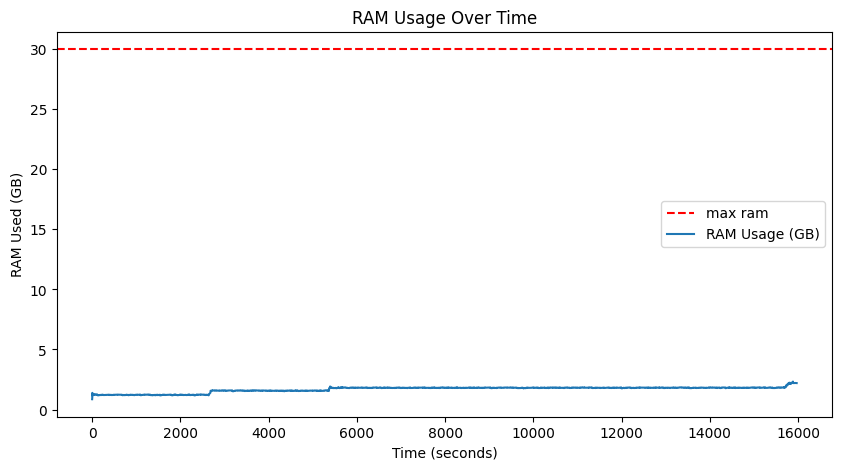

In [30]:
plt.figure(figsize=(10, 5))
plt.axhline(y=30, color='r', linestyle='--', label="max ram")
plt.plot(timestamps, mem_usage, label="RAM Usage (GB)")
plt.xlabel("Time (seconds)")
plt.ylabel("RAM Used (GB)")
plt.title("RAM Usage Over Time")
plt.legend()
plt.show()
# plt.savefig("ram_usage.png", dpi=300, bbox_inches='tight')